In [1]:
%%capture
!pip install -U bitsandbytes

In [2]:
from datasets import load_dataset
from IPython.display import display
import torch, torch.nn as nn, math, os
from torch.optim.lr_scheduler import OneCycleLR
from torch.utils.data import Dataset, DataLoader
from transformers import (BitsAndBytesConfig, AutoModelForCausalLM, 
                          AutoTokenizer, AutoProcessor, AutoModel)
from peft import prepare_model_for_kbit_training, LoraConfig, get_peft_model, TaskType

In [3]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()

class BlipParamConfig:
    hf_key = user_secrets.get_secret("huggingface_api")
    dataset_name="astro21/coco-caption-train-split-33k"
    vision_processor_name = "google/siglip-so400m-patch14-384"
    llm_model_name = "Qwen/Qwen3-0.6B"
    embedding_dim = 1024
    vision_dim_model = 1152
    max_length=1024
    layer_bias = True
    batch_size = 4
    shuffle = True
    n_heads = 16
    truncation = True
    padding = True
    dropout = 0
    n_queries = 32
    n_layers = 12
    device = "cuda"

In [4]:
vqa_dataset = load_dataset(BlipParamConfig.dataset_name)

vqa_dataset

README.md:   0%|          | 0.00/435 [00:00<?, ?B/s]

data/train-00000-of-00011.parquet:   0%|          | 0.00/488M [00:00<?, ?B/s]

data/train-00001-of-00011.parquet:   0%|          | 0.00/485M [00:00<?, ?B/s]

data/train-00002-of-00011.parquet:   0%|          | 0.00/491M [00:00<?, ?B/s]

data/train-00003-of-00011.parquet:   0%|          | 0.00/492M [00:00<?, ?B/s]

...

data/train-00008-of-00011.parquet:   0%|          | 0.00/487M [00:00<?, ?B/s]

data/train-00009-of-00011.parquet:   0%|          | 0.00/488M [00:00<?, ?B/s]

data/train-00010-of-00011.parquet:   0%|          | 0.00/489M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/33128 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image_id', 'id', 'caption', 'image', 'folder'],
        num_rows: 33128
    })
})

In [5]:
vqa_dataset  = vqa_dataset["train"]#.select(range(10))

In [6]:
vqa_dataset

Dataset({
    features: ['image_id', 'id', 'caption', 'image', 'folder'],
    num_rows: 33128
})

In [7]:
class BlipDataSet(Dataset):
    def __init__(self, dataset, tokenizer):
        self.image = dataset["image"]
        self.caption = dataset["caption"]
        self.tokenizer = tokenizer
        
    def prep_input_text(self, sample):
        text = [
            {"role": "system",    "content": "You are an expert image captioning assistant."},
            {"role": "user",      "content": "Write a natural, single-sentence caption describing the image."},
            {"role": "assistant", "content": sample}
        ]
        return self.tokenizer.apply_chat_template(
            text,
            tokenize=False,
            add_generation_prompt=False,
            enable_thinking=False
        )

    def __len__(self):
        return len(self.image)
        
    def __getitem__(self, index):
        image = self.image[index]
        text = self.prep_input_text(self.caption[index])
        return image, text

In [8]:
model = AutoModelForCausalLM.from_pretrained(BlipParamConfig.llm_model_name,
                                             torch_dtype=torch.bfloat16,
                                             device_map="auto",
                                             quantization_config=BitsAndBytesConfig(
                                                 load_in_4bit=True,
                                                 bnb_4bit_quant_type="nf4",
                                                 bnb_4bit_compute_dtype=torch.bfloat16,
                                                 bnb_4bit_use_double_quant=True,
                                             ))

model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=4,
    lora_alpha=4,
    lora_dropout=0.0,
    bias="none",
    target_modules="all-linear",
)

model = get_peft_model(model, lora_config)

text_tokenizer = AutoTokenizer.from_pretrained(BlipParamConfig.llm_model_name, token=BlipParamConfig.hf_key)
text_tokenizer.pad_token = text_tokenizer.eos_token

vision_model = AutoModel.from_pretrained(BlipParamConfig.vision_processor_name).to(model.device)
vision_processor = AutoProcessor.from_pretrained(BlipParamConfig.vision_processor_name)

config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


...

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer_config.json:   0%|          | 0.00/711 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [9]:
text_tokenizer.chat_template = """{%- for message in messages %}
    {%- if message.role == "system" %}
        {{- '<|im_start|>system\n' + message.content + '<|im_end|>\n' }}
    {%- elif message.role == "user" %}
        {{- '<|im_start|>user\n' + message.content + '<|im_end|>\n' }}
    {%- elif message.role == "assistant" %}
        {{- '<|im_start|>assistant\n' + message.content + '<|im_end|>\n' }}
    {%- endif %}
{%- endfor %}
{%- if add_generation_prompt %}
    {{- '<|im_start|>assistant\n<think>\n\n</think>\n' }}
{%- endif %}"""

In [10]:
vqa_tts = vqa_dataset.train_test_split(test_size=.3)

vqa_tts

DatasetDict({
    train: Dataset({
        features: ['image_id', 'id', 'caption', 'image', 'folder'],
        num_rows: 23189
    })
    test: Dataset({
        features: ['image_id', 'id', 'caption', 'image', 'folder'],
        num_rows: 9939
    })
})

In [11]:
def collate_fn(batch):
    image = [i[0].convert("RGB") for i in batch]
    label = [i[1] for i in batch]
    return image, label

blip_train_ds = BlipDataSet(vqa_tts["train"], 
                            text_tokenizer)
blip_train_dl = DataLoader(blip_train_ds,
                           batch_size=BlipParamConfig.batch_size, 
                           shuffle=BlipParamConfig.shuffle, 
                           collate_fn=collate_fn)

blip_val_ds = BlipDataSet(vqa_tts["test"],
                          text_tokenizer)
blip_val_dl = DataLoader(blip_val_ds, 
                         batch_size=BlipParamConfig.batch_size, 
                         shuffle=not BlipParamConfig.shuffle, 
                         collate_fn=collate_fn)

In [12]:
img, txt = next(iter(blip_val_dl))

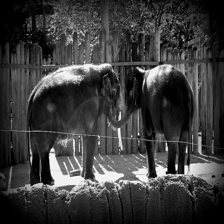

Captions: <|im_start|>system
You are an expert image captioning assistant.<|im_end|>
<|im_start|>user
Write a natural, single-sentence caption describing the image.<|im_end|>
<|im_start|>assistant
Two elephants that are looking at each other.<|im_end|>



In [13]:
display(img[0].resize((224, 224)))
print("Captions:", txt[0])

In [14]:
class QFormerAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        assert config.embedding_dim % config.n_heads == 0, f"n_heads={config.n_heads} must divide embedding_dim={config.embedding_dim}"
        self.d_k = config.embedding_dim // config.n_heads

        self.q_proj      = nn.Linear(config.embedding_dim, config.embedding_dim, bias=config.layer_bias)
        self.k_proj      = nn.Linear(config.embedding_dim, config.embedding_dim, bias=config.layer_bias)
        self.v_proj      = nn.Linear(config.embedding_dim, config.embedding_dim, bias=config.layer_bias)
        self.output_proj = nn.Linear(config.embedding_dim, config.embedding_dim, bias=config.layer_bias)

    def split_heads(self, x):
        B, N, _ = x.shape
        return x.view(B, N, self.config.n_heads, self.d_k).transpose(1, 2)

    def forward(self, query, key_value):
        """
        query     : (B, n_queries, embedding_dim)
        key_value : (B, T_kv,     embedding_dim)
                    — same tensor as query for self-attention
                    — image patch features for cross-attention
        N -> sequence length
        """
        B, N, _ = query.shape

        q = self.split_heads(self.q_proj(query))      # (B, H, N, d_k)
        k = self.split_heads(self.k_proj(key_value))  # (B, H, T_kv, d_k)
        v = self.split_heads(self.v_proj(key_value))  # (B, H, T_kv, d_k)

        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_k)  # (B, H, N, T_kv)
        att = torch.softmax(att, dim=-1)

        out = att @ v                                           # (B, H, N, d_k)
        out = out.transpose(1, 2).contiguous().view(B, N, -1)  # (B, N, embedding_dim)
        return self.output_proj(out)


class QFormerLayer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.self_attention  = QFormerAttention(config)
        self.cross_attention = QFormerAttention(config)

        self.norm1 = nn.LayerNorm(config.embedding_dim)
        self.norm2 = nn.LayerNorm(config.embedding_dim)
        self.norm3 = nn.LayerNorm(config.embedding_dim)

        self.ffn = nn.Sequential(
            nn.Linear(config.embedding_dim, 4 * config.embedding_dim),
            nn.GELU(),
            nn.Dropout(config.dropout),
            nn.Linear(4 * config.embedding_dim, config.embedding_dim),
            nn.Dropout(config.dropout),
        )

    def forward(self, queries, image_feat):
        # Self-attention: queries attend to themselves
        queries = queries + self.self_attention(self.norm1(queries), self.norm1(queries))

        # Cross-attention: queries attend to image patches
        queries = queries + self.cross_attention(self.norm2(queries), image_feat)
        
        # Feed-forward
        queries = queries + self.ffn(self.norm3(queries))

        return queries


class QFormer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        
        self.img_to_llm_proj = nn.Linear(config.vision_dim_model, config.embedding_dim, bias=config.layer_bias)

        self.query_tokens = nn.Parameter(torch.zeros(1, config.n_queries, config.embedding_dim))
        nn.init.trunc_normal_(self.query_tokens, std=0.02)

        self.layers = nn.ModuleList([QFormerLayer(config) for _ in range(config.n_layers)])
        self.norm   = nn.LayerNorm(config.embedding_dim)

    def forward(self, image_features):
        """
        image_features: (B, n_patches, vision_dim_model)
        returns:        (B, n_queries, embedding_dim)
        """
        B = image_features.size(0)

        # Project once
        img = self.img_to_llm_proj(image_features)  # (B, n_patches, embedding_dim)

        queries = self.query_tokens.expand(B, -1, -1)  # (B, n_queries, embedding_dim)

        for layer in self.layers:
            queries = layer(queries, img)

        return self.norm(queries)

In [15]:
qformer = QFormer(BlipParamConfig)

In [16]:
class BlipProcessor(nn.Module):
    def __init__(self, config, image_processor, text_processor):
        super().__init__()
        self.config = config
        self.text_processor = text_processor
        self.image_processor = image_processor

    def preprocess_image(self, image):
        return self.image_processor(image, return_tensors="pt")["pixel_values"].to(self.config.device)

    def preprocess_text(self, text):
        prep_text = self.text_processor(text, 
                                        return_tensors="pt",
                                        padding=self.config.padding, 
                                        truncation=self.config.truncation, 
                                        max_length=self.config.max_length).to(self.config.device)
        input_ids = prep_text["input_ids"]
        attention_mask = prep_text["attention_mask"]
        return input_ids, attention_mask
        
    def forward(self, image, text):
        image = self.preprocess_image(image)
        input_ids, attention_mask = self.preprocess_text(text)
        return image, input_ids, attention_mask

In [17]:
blip_processor = BlipProcessor(BlipParamConfig, vision_processor, text_tokenizer)

In [18]:
class BLIP2Model(nn.Module):
    def __init__(self, config, text_model, image_model, qformer, blip_processor):
        super().__init__()
        self.config          = config
        self.image_model     = image_model
        self.text_model      = text_model
        self.qformer         = qformer
        self.blip_processor  = blip_processor

        for param in self.image_model.parameters():
            param.requires_grad = False
        for param in self.text_model.parameters():
            param.requires_grad = False

    def create_label(self, txt_input_ids, label_indicator="<|im_start|>assistant"):
        indicator_ids = self.blip_processor.text_processor.encode(label_indicator, add_special_tokens=False)
        input_ids = txt_input_ids.clone()
        input_ids[input_ids == self.blip_processor.text_processor.pad_token_id] = -100
    
        for i in range(input_ids.shape[0]):
            ids = input_ids[i].tolist()
            for j in range(len(ids) - len(indicator_ids) + 1):
                if ids[j:j + len(indicator_ids)] == indicator_ids:
                    input_ids[i, :j + len(indicator_ids)] = -100
                    break
                    
        return input_ids

    def forward(self, image, text, inference=False):
        # Preprocessing 
        pixel_values, input_ids, attn_mask = self.blip_processor(image, text)

        # Frozen ViT 
        with torch.no_grad():
            image_features = self.image_model.vision_model(pixel_values).last_hidden_state[:, 1:, :]

        # Q-Former
        query_output  = self.qformer(image_features) # (B, n_queries, embedding_dim)

        # Prepend visual tokens to text embeddings
        text_embeds    = self.text_model.get_input_embeddings()(input_ids)
        inputs_embeds  = torch.cat([query_output, text_embeds], dim=1)

        # Extend attention mask
        visual_attn_mask = torch.ones((pixel_values.shape[0],
                                       query_output.shape[1]),
                                      dtype=attn_mask.dtype,
                                      device=pixel_values.device)
        
        full_attn_mask = torch.cat([visual_attn_mask, attn_mask], dim=1)
    
        # Labels
        labels = None
        if not inference:
            raw_labels = self.create_label(input_ids)
            
            visual_label_mask = torch.full((pixel_values.size(0), query_output.size(1)), 
                                           fill_value=-100,
                                           dtype=raw_labels.dtype, 
                                           device=pixel_values.device)
            
            labels = torch.cat([visual_label_mask, raw_labels], dim=1)

        return self.text_model(
                inputs_embeds=inputs_embeds,
                attention_mask=full_attn_mask,
                labels=labels,
            )

In [19]:
blip_model = BLIP2Model(BlipParamConfig,
                        model,
                        vision_model, 
                        qformer, 
                        blip_processor).to(BlipParamConfig.device)

In [20]:
def InferenceMode(trainer, image, text_prompt, config):
    model = trainer.blip_model if hasattr(trainer, "blip_model") else trainer
    
    model.eval()
    with torch.no_grad():
        pixel_values, input_ids, attn_mask = blip_processor(image, text_prompt)  
        image_features = model.image_model.vision_model(pixel_values).last_hidden_state[:, 1:, :]
        
        query_output  = model.qformer(image_features) 
        text_embeds    = model.text_model.get_input_embeddings()(input_ids)
        
        inputs_embeds  = torch.cat([query_output, text_embeds], dim=1)

        # Extend attention mask
        visual_attn_mask = torch.ones((pixel_values.shape[0],
                                       query_output.shape[1]),
                                       dtype=attn_mask.dtype,
                                       device=config.device)
        
        full_attn_mask = torch.cat([visual_attn_mask, attn_mask], dim=1)
        
        generated_ids = model.text_model.generate(
            inputs_embeds=inputs_embeds,
            attention_mask=full_attn_mask,
            max_new_tokens=256,        
            do_sample=False,
            repetition_penalty=1.2,
            pad_token_id=blip_processor.text_processor.pad_token_id,
            eos_token_id=blip_processor.text_processor.eos_token_id,
        )
    decoded = blip_processor.text_processor.batch_decode(
        generated_ids, skip_special_tokens=True
    )
    return decoded[0]

### Before Training

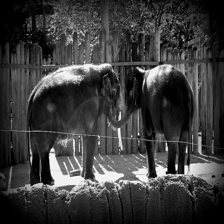

Captions:
 <|im_start|>system
You are an expert image captioning assistant.<|im_end|>
<|im_start|>user
Write a natural, single-sentence caption describing the image.<|im_end|>
<|im_start|>assistant
Two elephants that are looking at each other.<|im_end|>

Model Caption:



The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


'�️️⁄️⁄️⁄️ⶾ����翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅翅'

In [21]:
display(img[0].resize((224, 224)))
print("Captions:\n", txt[0])

print("Model Caption:\n")
InferenceMode(blip_model, img[0], txt[0], BlipParamConfig)

In [22]:
class Blip2Trainer:
    def __init__(self, model, train_dl, val_dl, optimizer, min_delta=1e-4, patience=3, epochs=2):
        self.train_dl = train_dl
        self.val_dl = val_dl
        self.blip_model = model
        self.optimizer = optimizer
        self.best_val_loss = float("inf")
        self.stop_training = False
        self.min_delta = min_delta
        self.patience = patience
        self._es_counter = 0
        self.epochs = epochs
        self.scheduler = OneCycleLR(
            optimizer,
            max_lr=1e-3,
            total_steps=self.epochs * len(train_dl),
            pct_start=0.03,
            anneal_strategy="cos"
        )

    def train(self):
        total_loss = 0
        self.blip_model.train()
        for image, text in self.train_dl:
            self.optimizer.zero_grad()
            
            output = self.blip_model(image, text)
            loss = output.loss
            total_loss += loss.item()
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.blip_model.qformer.parameters(), max_norm=1.0)
            self.optimizer.step()
            self.scheduler.step()
            
        avg_loss = total_loss / len(self.train_dl)
        return avg_loss

    def evaluate(self):
        total_loss = 0
        self.blip_model.eval()
        for image, text in self.val_dl:
            with torch.no_grad():
                output = self.blip_model(image, text)
                loss = output.loss
                total_loss += loss.item()
        avg_loss = total_loss / len(self.val_dl)
        return avg_loss

    def check_early_stopping(self, val_loss):
        if val_loss < self.best_val_loss - self.min_delta:
            self.best_val_loss = val_loss
            self._es_counter = 0
            return True   
        else:
            self._es_counter += 1
            if self._es_counter >= self.patience:
                self.stop_training = True
            return False  

    def save_checkpoint(self, checkpoint_dir="checkpoints", name="qformer_best"):
        os.makedirs(checkpoint_dir, exist_ok=True)
        pt_path = os.path.join(checkpoint_dir, f"{name}.pt")
        torch.save({"qformer_state_dict": self.blip_model.qformer.state_dict()}, pt_path)

    def load_checkpoint(self, checkpoint_dir="checkpoints", name="qformer_best"):
        pt_path = os.path.join(checkpoint_dir, f"{name}.pt")
        ckpt = torch.load(pt_path, map_location=next(self.blip_model.qformer.parameters()).device)
        self.blip_model.qformer.load_state_dict(ckpt["qformer_state_dict"])
        print(f"  ✔ Loaded best model")

    def fit(self, warmup_epochs=0):
        for epoch in range(self.epochs):
            train_loss = self.train()
            val_loss   = self.evaluate()
            improved   = self.check_early_stopping(val_loss)
            print(
                f"Epoch {epoch+1}/{self.epochs} | "
                f"Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
                f"ES: {self._es_counter}/{self.patience}"
            )
            if improved and epoch >= warmup_epochs:
                self.save_checkpoint()
            if self.stop_training:
                print(f"Early stopping triggered at epoch {epoch+1}.")
                break

In [23]:
optimizer = torch.optim.AdamW([{"params": blip_model.qformer.parameters(), "lr": 1e-4}])

In [24]:
trainer = Blip2Trainer(blip_model, blip_train_dl, blip_val_dl, optimizer)

In [25]:
trainer.fit()

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch 1/2 | Train: 2.6828 | Val: 2.5012 | ES: 0/3
Epoch 2/2 | Train: 2.4528 | Val: 2.4202 | ES: 0/3
